In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum() # No missing 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# TotalCharges feature is in string need in numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"] , errors='coerce') # Convert to numeric, forcing errors to NaN

In [7]:
print(f"Missing values after conversion: {df['TotalCharges'].isnull().sum()}")

Missing values after conversion: 11


In [8]:
df = df.dropna() # removing 11 records

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# EDA 

#### **Gender Distribution**

In [11]:
df["gender"].value_counts() # Total 3549 is a male and 3483 is Fermale Customer

gender
Male      3549
Female    3483
Name: count, dtype: int64

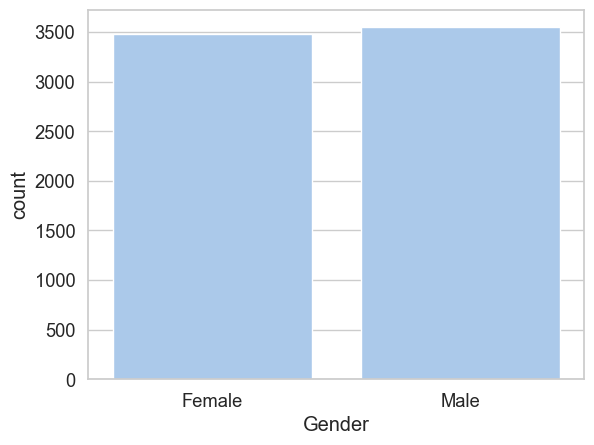

In [12]:
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

sns.countplot(x = df["gender"])
plt.xlabel("Gender")
plt.show()

In [13]:
counts = df["gender"].value_counts()
percentage = df["gender"].value_counts(normalize = True) * 100
summery =pd.DataFrame({
    "Count" : counts ,
    "Percentage" : percentage.round(1)
})
print(summery)

        Count  Percentage
gender                   
Male     3549        50.5
Female   3483        49.5


#### Grouping by SeniorCitizen to see their behavior

In [14]:
real_world_stats = df.groupby('gender').agg({
    'MonthlyCharges': 'mean',
    'Churn': lambda x: (x == 'Yes').mean() * 100  # Percentage of people who left
}).round(2)

print(real_world_stats)

        MonthlyCharges  Churn
gender                       
Female           65.22  26.96
Male             64.39  26.20


### **Senior Citizen Behavioral Patterns**

In [15]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [16]:
counts = df["SeniorCitizen"].value_counts()
percentage = df["SeniorCitizen"].value_counts(normalize = True) * 100
summery =pd.DataFrame({
    "Count" : counts ,
    "Percentage" : percentage.round(1)
})
print(summery)

               Count  Percentage
SeniorCitizen                   
0               5890        83.8
1               1142        16.2


##### Grouping by SeniorCitizen to see their behavior


In [17]:
real_world_stats = df.groupby('SeniorCitizen').agg({
    'MonthlyCharges': 'mean',
    'Churn': lambda x: (x == 'Yes').mean() * 100  # Percentage of people who left
}).round(2)

print(real_world_stats)

               MonthlyCharges  Churn
SeniorCitizen                       
0                       61.89  23.65
1                       79.82  41.68


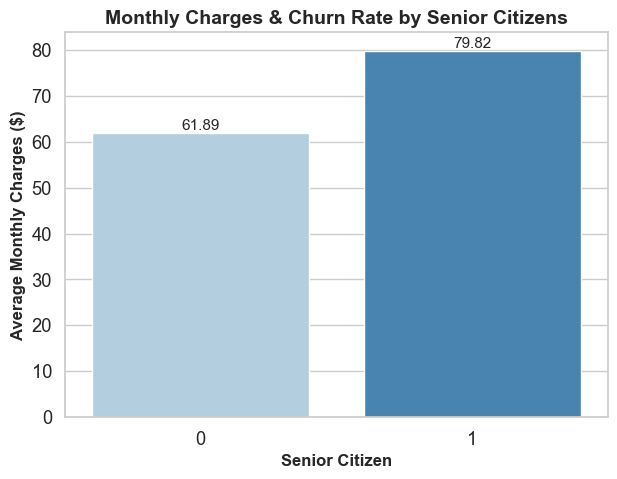

In [18]:
sns.set(style="whitegrid", font_scale=1.2)
fig, ax1 = plt.subplots(figsize=(7,5))

# Average Monthly Charges
sns.barplot(
    x=real_world_stats.index, 
    y=real_world_stats['MonthlyCharges'], 
    palette="Blues", 
    ax=ax1
)
ax1.set_ylabel("Average Monthly Charges ($)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Senior Citizen", fontsize=12, fontweight='bold')
ax1.set_title("Monthly Charges & Churn Rate by Senior Citizens", fontsize=14, fontweight='bold')

# Show values on bars
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=11)

plt.show()

- we can simple see that the SeniorCitizen pays more as compare to younger 
- Even though there are fewer seniors, each one is worth about 29% more revenue than a younger customer. They are likely buying premium packages, faster internet, or more TV channels.
- eniors are leaving the company at an alarming rate.
- Non-Seniors Churn: 23.65% (About 1 in 4 leave).
- Seniors Churn: 41.68% (Nearly half of them leave!).
- **The Insight: This is a huge "red flag." You are losing your highest-paying customers twice as fast as your younger ones.**

### **Safety Net Analysis**

In [19]:
real_world_stats = df.groupby('Partner').agg({
    # Percentage of people who HAVE dependents
    'Dependents': lambda x: (x == 'Yes').mean() * 100, 
    # Percentage of people who CHURNED
    'Churn': lambda x: (x == 'Yes').mean() * 100
}).round(2)

# Renaming columns for clarity
real_world_stats.columns = ['Has_Dependents_%', 'Churn_Rate_%']
print(real_world_stats)

         Has_Dependents_%  Churn_Rate_%
Partner                                
No                   9.87         32.98
Yes                 51.28         19.72


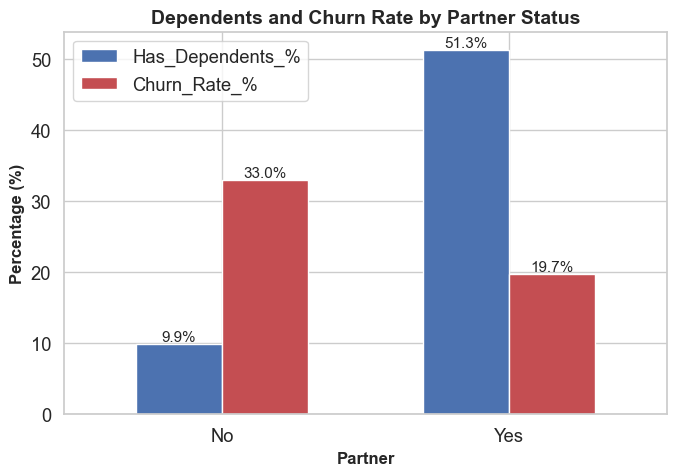

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Prepare figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot side-by-side bars
real_world_stats.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], width=0.6)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

# Labels and title
ax.set_xlabel("Partner", fontsize=12, fontweight='bold')
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight='bold')
ax.set_title("Dependents and Churn Rate by Partner Status", fontsize=14, fontweight='bold')
ax.set_xticklabels(real_world_stats.index, rotation=0)

plt.tight_layout()
plt.show()

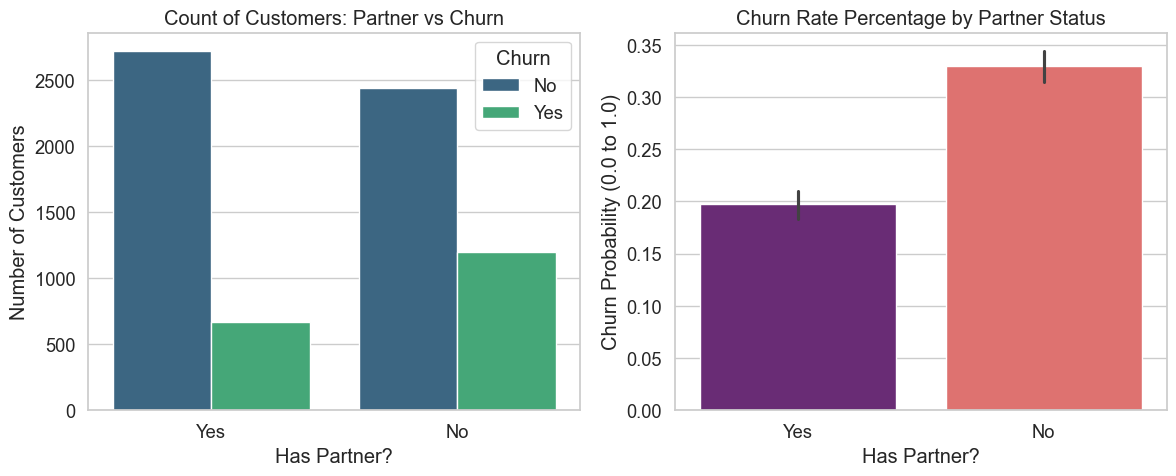

In [21]:

# Pre-processing for visualization
# Converting Churn to 0/1 for the barplot to represent probability/percentage
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 1. Count Plot: Shows the Volume (How many people are in each group)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Partner', hue='Churn', palette='viridis')
plt.title('Count of Customers: Partner vs Churn')
plt.xlabel('Has Partner?')
plt.ylabel('Number of Customers')

# 2. Bar Plot: Shows the Rate (What % of that group left)
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Partner', y='Churn_Numeric', palette='magma')
plt.title('Churn Rate Percentage by Partner Status')
plt.xlabel('Has Partner?')
plt.ylabel('Churn Probability (0.0 to 1.0)')

plt.tight_layout()
plt.savefig('partner_churn_analysis.png')

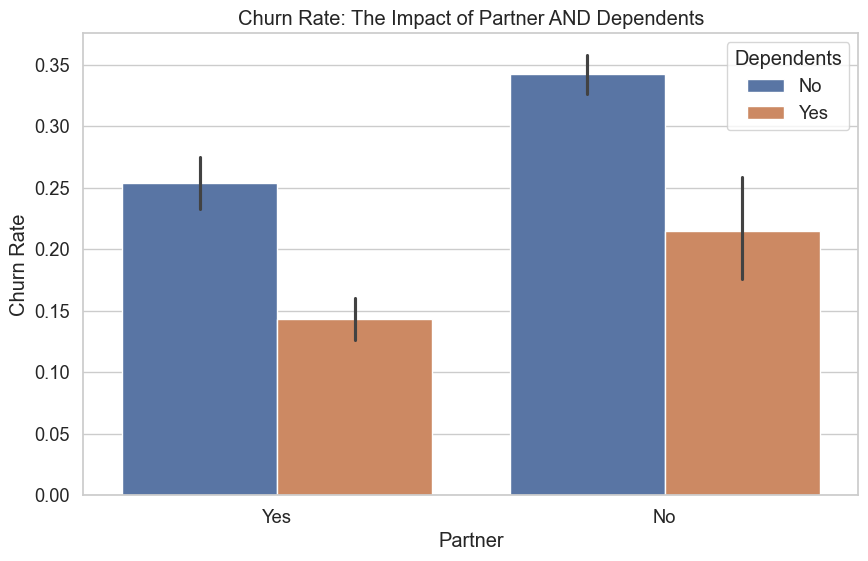

In [22]:
# 3. Multi-Variable Visual: Partner vs Dependents vs Churn
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Partner', y='Churn_Numeric', hue='Dependents')
plt.title('Churn Rate: The Impact of Partner AND Dependents')
plt.ylabel('Churn Rate')
plt.savefig('family_structure_churn.png')

In [23]:
# Check if "Safety Net" customers stay longer on average
df.groupby(['Partner', 'Dependents'])['tenure'].mean()

Partner  Dependents
No       No            23.303354
         Yes           23.986072
Yes      No            42.709014
         Yes           41.578161
Name: tenure, dtype: float64

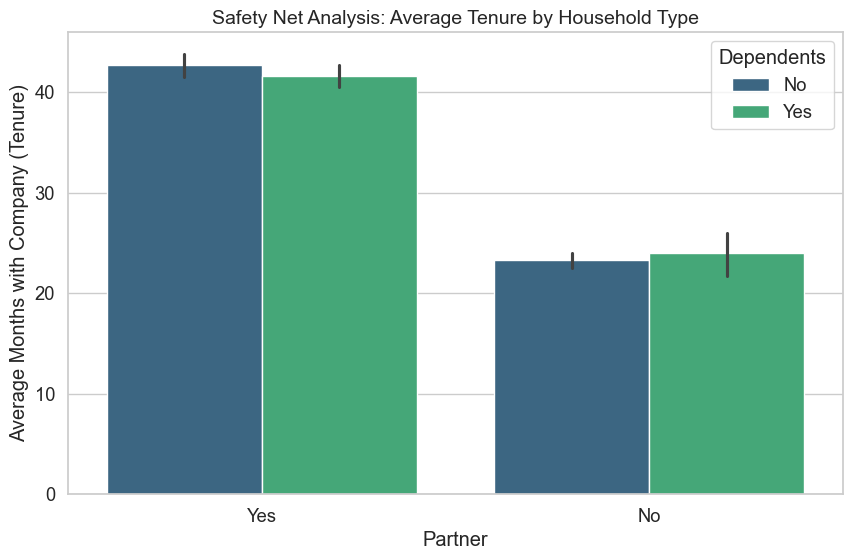

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Partner', y='tenure', hue='Dependents', palette='viridis')

plt.title("Safety Net Analysis: Average Tenure by Household Type", fontsize=14)
plt.ylabel("Average Months with Company (Tenure)")
plt.show()

<Figure size 1200x1200 with 0 Axes>

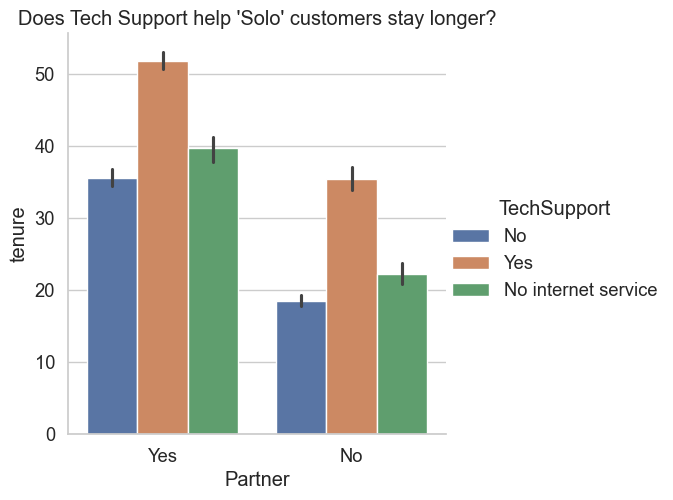

In [25]:
# PRO APPROACH: Compare Tenure, Service (TechSupport), and Household Type
plt.figure(figsize =(12 ,12))
sns.catplot(data=df, x='Partner', y='tenure', hue='TechSupport', kind='bar')
plt.title("Does Tech Support help 'Solo' customers stay longer?")
plt.show()

In [26]:
# Verifying the Social Anchor Effect
real_world_stats = df.groupby('Partner').agg({
    'Dependents': lambda x: (x == 'Yes').mean() * 100,
    'Churn': lambda x: (x == 'Yes').mean() * 100,
    'tenure': 'mean'
}).round(2)
display(real_world_stats)

,Dependents,Churn,tenure
Partner,,,
No,9.87,32.98,23.37
Yes,51.28,19.72,42.13


# 🛡️ Safety Net Analysis: The Impact of Household Structure

## 🎯 Objective
To determine whether having a **Partner** or **Dependents** acts as a **"Social Anchor"**, increasing **customer loyalty (tenure)** and reducing the probability of **customer churn**.

---

## 1. Key Metrics Summary

Our initial grouping reveals a significant **loyalty gap** between **solo customers** and those with **family structures**.

| Household Type | Dependents (%) | Churn Rate (%) | Avg. Tenure (Months) |
|----------------|---------------|---------------|----------------------|
| **Solo (No Partner)** | 9.87% | **32.98% (High Risk)** | ~23.3 |
| **Partnered** | 51.28% | **19.72% (Stable)** | ~42.1 |

### 🔎 Key Insight
Customers with partners remain subscribed **almost twice as long** as solo customers, indicating a strong **household stability effect**.

---

## 2. Behavioral Interpretations

### A. The **Partner Loyalty Premium**

**Observation**

Customers with a **Partner** stay subscribed for nearly **42 months**, compared to **23 months** for customers without partners.

**Insight**

A partner acts as a **social anchor**. Switching providers for a **multi-person household** introduces more **decision friction** than it does for a single individual.

Therefore, partnered customers show **higher stability and loyalty**.

---

### B. The **Solo Risk Factor**

**Observation**

Customers with **no partner and no dependents** show the **highest churn rate (32.98%)**.

**Insight**

These customers are **highly mobile**:

- More likely to switch providers for competitor promotions
- More likely to cancel services when relocating
- Lower emotional or logistical attachment to the service

Without a **household safety net**, their **commitment to the service is weaker**.

---

### C. The **Tech Support Loyalty Booster**

Using **categorical plots (catplot)**, we observe that **Tech Support significantly increases tenure** for both household groups.

**Example Insight**

For **solo customers**:

- Without Tech Support → Tenure **below 20 months**
- With Tech Support → Tenure **around 35 months**

This demonstrates that **value-added services can partially replace the “Social Anchor” effect**.

---

## 3. Business Recommendations 📈

Based on the **Safety Net Analysis**, the following strategic actions are recommended.

### 1. Targeted Retention Strategy
Implement a **"Save Desk" retention trigger** for **solo customers around the 22-month mark**, as churn probability increases around **month 23**.

---

### 2. Product Bundling Strategy
Promote **Family Plans or Multi-User Discounts**.

Encouraging a solo user to **add a partner or family member** can:

- Increase **Customer Lifetime Value (CLV)**
- Improve **long-term retention**
- Reduce **churn probability**

---

### 3. Digital Safety Net Strategy
For **solo customers**, bundle additional services such as:

- **Tech Support**
- **Online Security**
- **Cloud Backup**

These services create **digital friction**, making customers **less likely to switch providers**, mimicking the stability seen in family households.

---

## 4. Technical Verification (Code)

The following Python code was used to validate the **Social Anchor Effect**.

```python
# Verifying the Social Anchor Effect

real_world_stats = df.groupby('Partner').agg({
    'Dependents': lambda x: (x == 'Yes').mean() * 100,
    'Churn': lambda x: (x == 'Yes').mean() * 100,
    'tenure': 'mean'
}).round(2)

display(real_world_stats)
```

---

## 📌 Conclusion

Household structure plays a **critical role in customer retention**.

**Key Takeaways**

- **Partnered households → higher loyalty**
- **Solo customers → highest churn risk**
- **Value-added services (like Tech Support) help increase retention**

Understanding these behavioral patterns allows businesses to design **more effective retention strategies and product bundles**.

### **Stickiness" Analysis (OnlineSecurity to TechSupport)**
> OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV,  StreamingMovies

In [27]:
# 1. Define the service columns (The "Sticky" features)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# 2. FEATURE CONSTRUCTION: Create the "Service_Count" score
# We convert 'Yes' to 1 and everything else to 0, then sum them up
df['Service_Count'] = (df[service_cols] == 'Yes').sum(axis=1)


stickiness_stats = df.groupby('Service_Count')['Churn_Numeric'].mean() * 100
print("Churn Rate by Number of Services (%):")
print(stickiness_stats.round(2))

Churn Rate by Number of Services (%):
Service_Count
0    21.46
1    45.76
2    35.82
3    27.39
4    22.35
5    12.48
6     5.28
Name: Churn_Numeric, dtype: float64


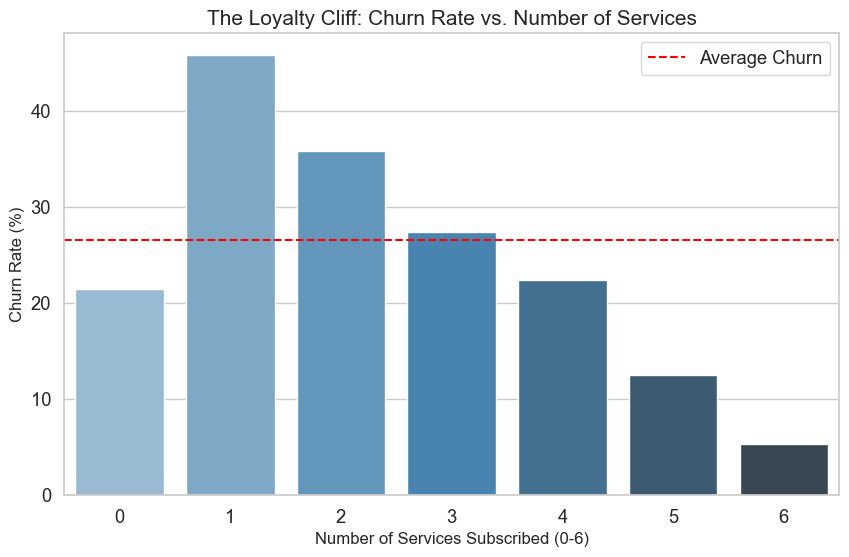

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x=stickiness_stats.index, y=stickiness_stats.values, palette='Blues_d')

plt.title('The Loyalty Cliff: Churn Rate vs. Number of Services', fontsize=15)
plt.xlabel('Number of Services Subscribed (0-6)', fontsize=12)
plt.ylabel ('Churn Rate (%)', fontsize=12)
plt.axhline(df['Churn_Numeric'].mean()*100, color='red', linestyle='--', label='Average Churn')
plt.legend()
plt.show()

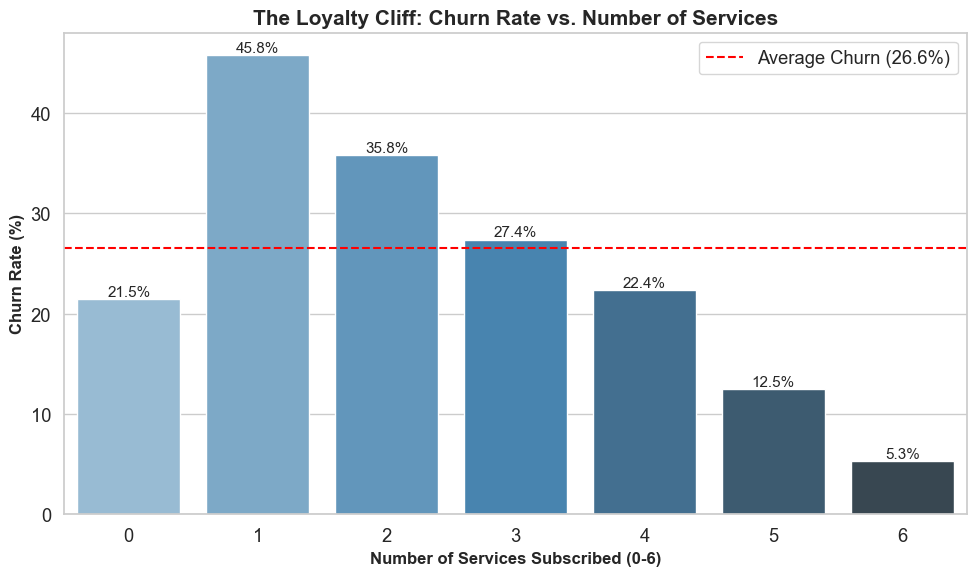

In [29]:
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10, 6))

# Barplot
ax = sns.barplot(
    x=stickiness_stats.index, 
    y=stickiness_stats.values, 
    palette='Blues_d'
)

# Add horizontal line for average churn
avg_churn = df['Churn_Numeric'].mean() * 100
plt.axhline(avg_churn, color='red', linestyle='--', label=f'Average Churn ({avg_churn:.1f}%)')

# Annotate bar values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

# Labels and title
plt.title('The Loyalty Cliff: Churn Rate vs. Number of Services', fontsize=15, fontweight='bold')
plt.xlabel('Number of Services Subscribed (0-6)', fontsize=12, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=12, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

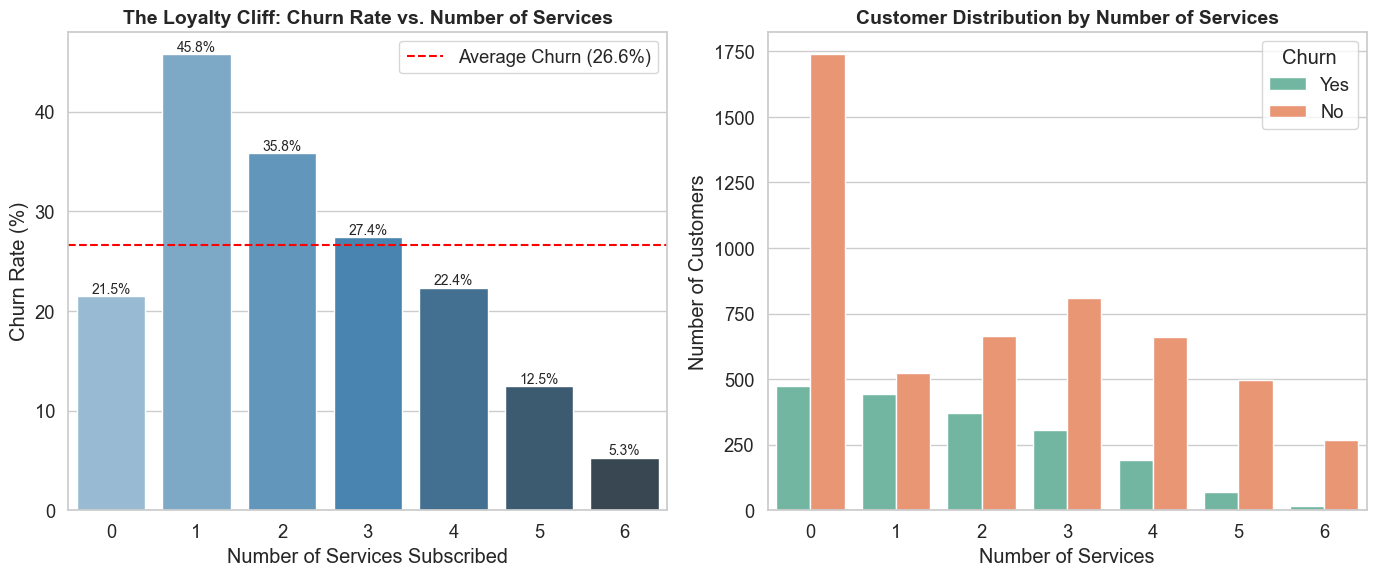

In [30]:
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(14,6))

# -------- Plot 1 : Churn Rate vs Number of Services --------
ax1 = plt.subplot(1,2,1)
sns.barplot(
    x=stickiness_stats.index, 
    y=stickiness_stats.values, 
    palette='Blues_d', 
    ax=ax1
)

# Annotate values
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10)

# Horizontal average churn line
avg_churn = df['Churn_Numeric'].mean() * 100
ax1.axhline(avg_churn, color='red', linestyle='--', label=f'Average Churn ({avg_churn:.1f}%)')
ax1.set_title('The Loyalty Cliff: Churn Rate vs. Number of Services', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Services Subscribed')
ax1.set_ylabel('Churn Rate (%)')
ax1.legend()

# -------- Plot 2 : Customer Distribution --------
ax2 = plt.subplot(1,2,2)
sns.countplot(
    x='Service_Count', 
    hue='Churn', 
    data=df, 
    palette='Set2', 
    ax=ax2
)
ax2.set_title('Customer Distribution by Number of Services', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Services')
ax2.set_ylabel('Number of Customers')
ax2.legend(title='Churn')

plt.tight_layout()
plt.show()

- There is a clear downward trend: More services → Lower churn
- Customers with 5–6 services almost never churn.
- This is called a Loyalty Effect or Service Stickiness.
- Look at this:

| Services | Churn Rate |
|---------|------------|
| 0       | 21%        |
| 1       | **45% (Highest)** |

- Customers with only 1 service churn the most.
- Meaning:
- 👉 They haven't integrated deeply into the ecosystem.
- Companies often try to cross-sell services to reduce churn.
- Example
- Internet only → High churn
- Internet + Security + Backup → Low churn
- Customers with more subscribed services show significantly lower churn rates. The churn rate drops from ~45% for customers with 1 service to ~5% for customers with 6 services, suggesting strong customer stickiness as service adoption increases.
- Recommendation:
- The company should promote bundle offers and cross-sell additional services to customers with 0–2 services to reduce churn risk.

## The "Infrastructure" Analysis (InternetService & MultipleLines)

In [31]:
# Calculate Churn Rate per Internet Service type
internet_analysis = df.groupby('InternetService').agg({
    'Churn_Numeric': 'mean',
    'MonthlyCharges': 'mean',
    'customerID': 'count'
}).rename(columns={'Churn_Numeric': 'Churn_Rate', 'customerID': 'Total_Customers'})

# Convert to percentage for easier reading
internet_analysis['Churn_Rate'] = (internet_analysis['Churn_Rate'] * 100).round(2)
print(internet_analysis)

                 Churn_Rate  MonthlyCharges  Total_Customers
InternetService                                             
DSL                   19.00       58.088017             2416
Fiber optic           41.89       91.500129             3096
No                     7.43       21.076283             1520


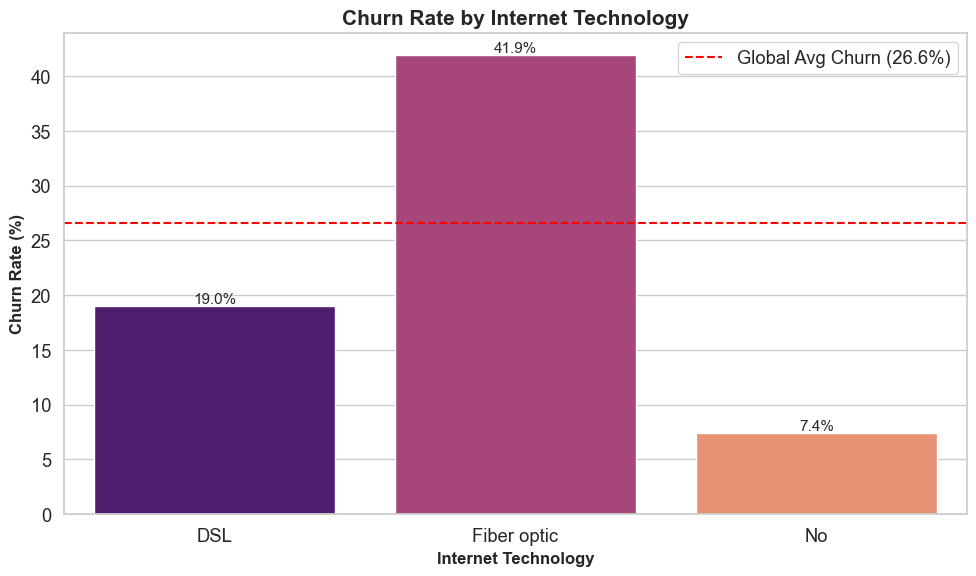

In [32]:
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Barplot
ax = sns.barplot(
    x=internet_analysis.index, 
    y='Churn_Rate', 
    data=internet_analysis, 
    palette='magma'
)

# Annotate bar values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

# Global average churn line
global_avg = df['Churn_Numeric'].mean() * 100
ax.axhline(global_avg, color='red', linestyle='--', label=f'Global Avg Churn ({global_avg:.1f}%)')

# Labels and title
ax.set_title('Churn Rate by Internet Technology', fontsize=15, fontweight='bold')
ax.set_xlabel('Internet Technology', fontsize=12, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

MultipleLines
No     45.768566
Yes    39.576883
Name: Churn_Numeric, dtype: float64


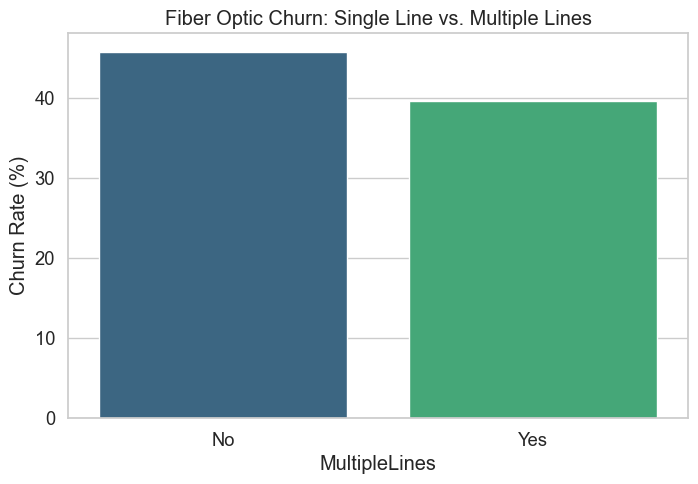

In [33]:
# Compare Fiber Optic churn with and without Multiple Lines
fiber_only = df[df['InternetService'] == 'Fiber optic']

fiber_anchor = fiber_only.groupby('MultipleLines')['Churn_Numeric'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=fiber_anchor.index, y=fiber_anchor.values, palette='viridis')
plt.title('Fiber Optic Churn: Single Line vs. Multiple Lines')
plt.ylabel('Churn Rate (%)')
print(fiber_anchor)
plt.show()

# 📡 Churn Analysis by Internet Technology


---

## 📊 Key Metrics Summary

| Internet Service | Churn Rate (%) | Avg Monthly Charges ($) | Total Customers |
|------------------|---------------|--------------------------|----------------|
| DSL              | 19.0%         | 58.09                    | 2416           |
| Fiber Optic      | 41.89%        | 91.50                    | 3096           |
| No Internet      | 7.43%         | 21.07                    | 1520           |

---

## 🔎 Key Insights

### 1️⃣ Fiber Optic Customers Show the Highest Churn
Fiber optic users have a **churn rate of 41.89%**, which is **far above the global average churn (~26%)**.

Possible reasons:
- Higher **monthly charges (~$91.5)** increase price sensitivity.
- Customers using fiber usually have **higher expectations for speed and reliability**.
- If service quality drops, these customers may **switch providers quickly**.

---

### 2️⃣ DSL Customers Show Moderate Loyalty
DSL customers have a **churn rate of 19%**, which is **below the global average**.

Possible explanation:
- DSL customers typically pay **moderate prices (~$58/month)**.
- Many DSL users may be in areas with **limited alternatives**, which naturally reduces churn.

---

### 3️⃣ Customers Without Internet Rarely Churn
Customers without internet service show the **lowest churn rate (7.43%)**.

Possible reasons:
- These customers likely subscribe to **basic services only (e.g., phone)**.
- Their **monthly charges are very low (~$21)**, making them less likely to leave.

---

# ⚡ Deeper Insight: Fiber Optic Customers

## Fiber Optic Churn — Single Line vs Multiple Lines

This analysis investigates whether having **multiple lines** affects churn among fiber optic customers.

| Multiple Lines | Churn Rate (%) |
|---------------|---------------|
| No            | ~46%          |
| Yes           | ~39%          |

### 🔎 Key Observation

Customers with **multiple lines churn less** than customers with a **single line**.

Possible explanation:
- Customers with multiple services are **more integrated into the ecosystem**.
- The **switching cost becomes higher**, reducing the likelihood of churn.

---

# 🧠 Business Interpretation

### 🚨 Risk Segment
**Fiber Optic customers with a single line**

This group represents the **highest churn risk** and should be prioritized for retention strategies.

---

### 💡 Recommended Actions

1. **Price Optimization**
   >Re-evaluate pricing for fiber optic plans.

2. **Bundle Services**
   >Encourage fiber users to adopt **multiple services (phone, streaming, security)**.

3. **Customer Experience Improvement**
   >Ensure **high-speed reliability and strong technical support** for fiber customers.

---

# 📌 Final Takeaway

The analysis reveals a clear **"Premium Service Paradox"**:

> Customers paying the **highest price (Fiber Optic)** are also the **most likely to churn**.

This suggests that **price expectations and service satisfaction play a critical role in retention**, especially for premium service tiers.

## Churn and Average Price by Payment Method

In [34]:
# 1. Calculate Churn and Average Price by Payment Method
billing_analysis = df.groupby('PaymentMethod').agg({
    'Churn_Numeric': 'mean',
    'MonthlyCharges': 'mean',
    'customerID': 'count'
}).rename(columns={'Churn_Numeric': 'Churn_Rate', 'customerID': 'Customer_Count'})

billing_analysis['Churn_Rate'] = (billing_analysis['Churn_Rate'] * 100).round(2)

# 2. Sort by Churn Rate to see the "Leakiest" method
print(billing_analysis.sort_values(by='Churn_Rate', ascending=False))

                           Churn_Rate  MonthlyCharges  Customer_Count
PaymentMethod                                                        
Electronic check                45.29       76.255814            2365
Mailed check                    19.20       43.958354            1604
Bank transfer (automatic)       16.73       67.205577            1542
Credit card (automatic)         15.25       66.519264            1521


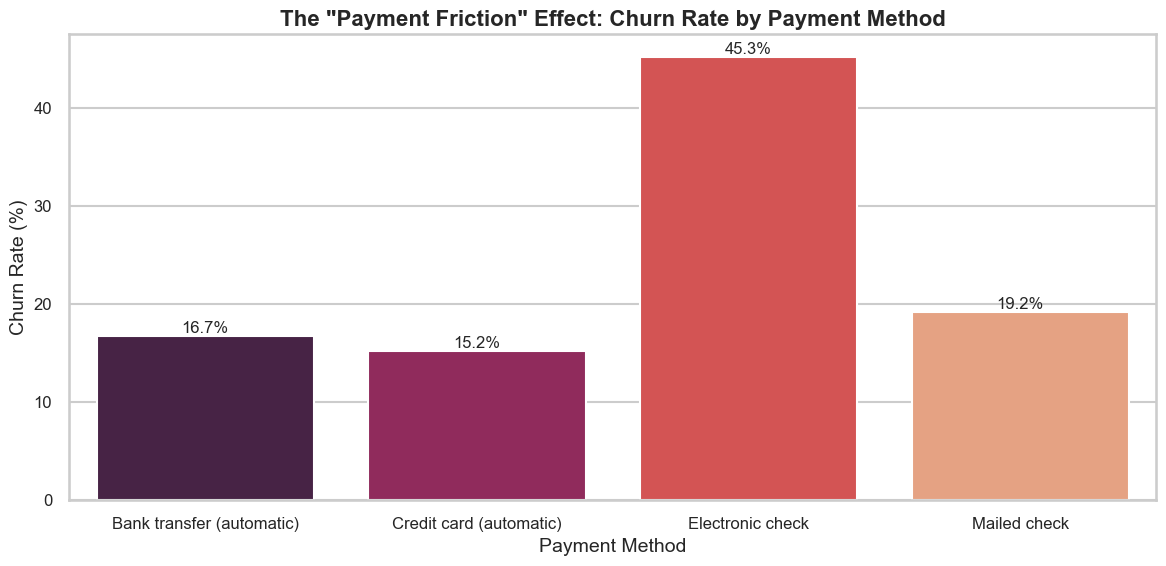

In [35]:
sns.set_style("whitegrid")
sns.set_context("talk")  # larger, presentation-ready fonts

plt.figure(figsize=(12, 6))

# Bar plot
ax = sns.barplot(
    x=billing_analysis.index, 
    y='Churn_Rate', 
    data=billing_analysis, 
    palette='rocket'
)

# Title and labels
plt.title('The "Payment Friction" Effect: Churn Rate by Payment Method', fontsize=16, weight='bold')
plt.ylabel('Churn Rate (%)', fontsize=14)
plt.xlabel('Payment Method', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Optional: Annotate bars with values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

- Customers using Electronic Checks churn at a much higher rate (often ~45%) compared to those on Credit Card (Auto) (often ~15%).
- Electronic check users aren't just "different people"—they are forced into a monthly decision cycle. Every month they "approve" the payment, they are essentially re-evaluating the service. If they have one bad experience that month, they are much more likely to quit.

## The "Contractual Loyalty" Analysis (Contract & PaymentMethod)
- Hypothesis: The "How" and "When" of payment dictates how easily someone can leave.
- Action: Use a Cross-tabulation between Contract and Churn.
> Look for the "Electronic Check" payment method. In the Telco dataset, this specific group usually has the highest churn.

In [36]:
pivot_risk = df.pivot_table(index='Contract', 
                            columns='PaymentMethod', 
                            values='Churn_Numeric', 
                            aggfunc='mean') * 100

print("The Churn Risk Matrix (%)")
print(pivot_risk.round(2))

The Churn Risk Matrix (%)
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Contract                                                             
Month-to-month                      34.13                    32.78   
One year                             9.72                    10.30   
Two year                             3.38                     2.24   

PaymentMethod   Electronic check  Mailed check  
Contract                                        
Month-to-month             53.73         31.58  
One year                   18.44          6.85  
Two year                    7.74          0.80  


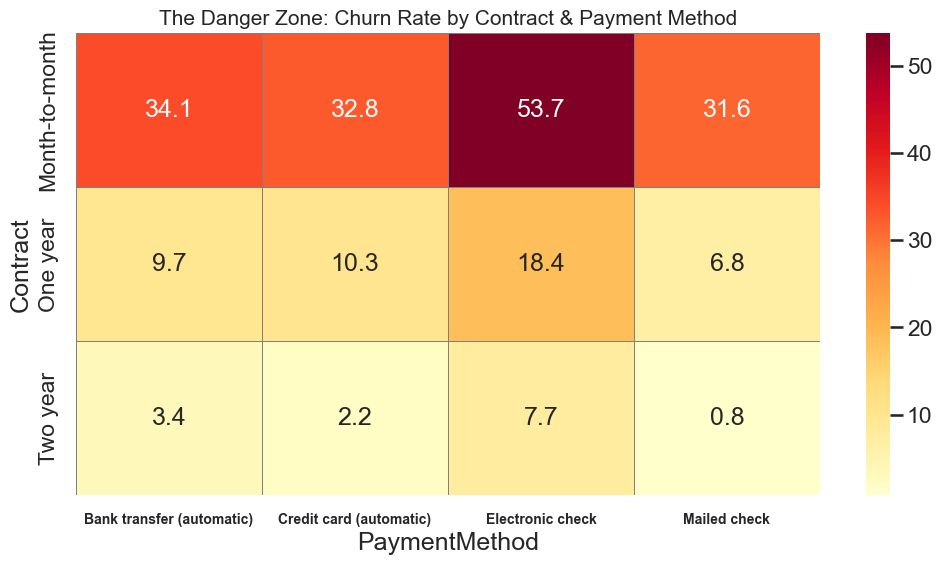

In [37]:
plt.figure(figsize=(12, 6))
# Using a "YlOrRd" (Yellow-Orange-Red) map makes high-risk areas pop out
sns.heatmap(pivot_risk, annot=True, cmap='YlOrRd', fmt='.1f' ,linewidths=0.5, 
    linecolor='gray')
plt.xlabel("PaymentMethod")
plt.xticks(rotation =0 , fontsize = 10 , fontweight='bold')
plt.title('The Danger Zone: Churn Rate by Contract & Payment Method', fontsize=15)
plt.show()

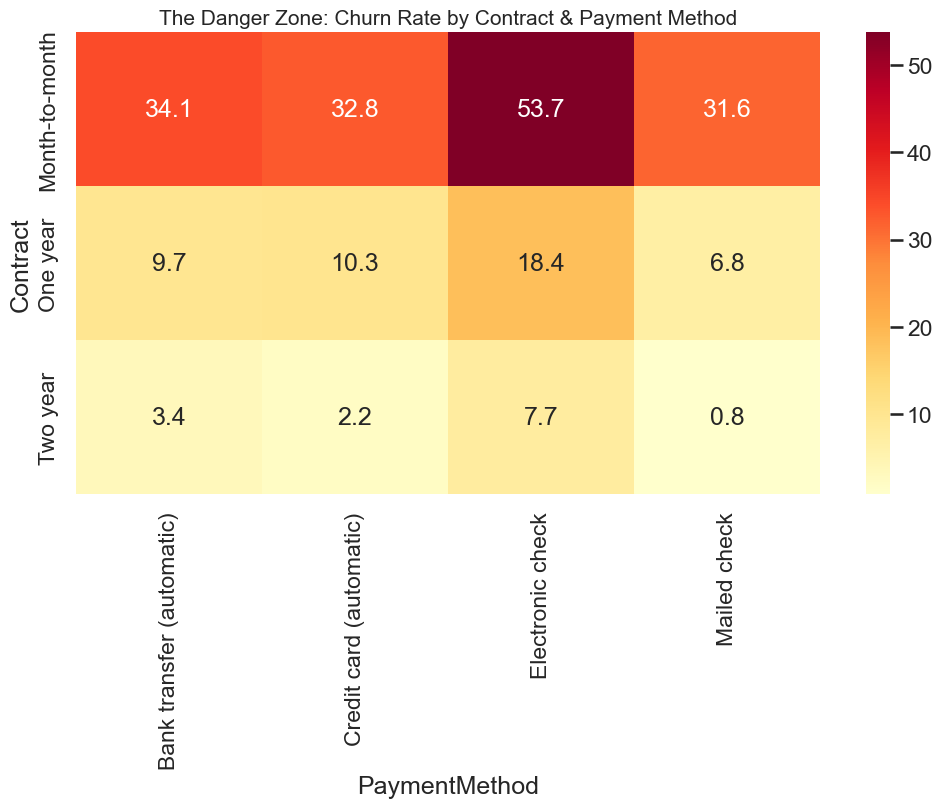

In [38]:
plt.figure(figsize=(12, 6))
# Using a "YlOrRd" (Yellow-Orange-Red) map makes high-risk areas pop out
sns.heatmap(pivot_risk, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('The Danger Zone: Churn Rate by Contract & Payment Method', fontsize=15)
plt.show()

# 🚨 The Danger Zone: Churn Risk by Contract Type & Payment Method

## 🎯 Objective
This analysis explores how **Contract Type** and **Payment Method** together influence customer churn.  
Both factors represent **customer commitment and billing behavior**, which are strong predictors of churn risk.

---

# 📊 Churn Risk Matrix (%)

| Contract | Bank Transfer (Auto) | Credit Card (Auto) | Electronic Check | Mailed Check |
|---------|----------------------|--------------------|-----------------|-------------|
| Month-to-Month | 34.13% | 32.78% | **53.73%** | 31.58% |
| One Year | 9.72% | 10.30% | 18.44% | 6.85% |
| Two Year | 3.38% | 2.24% | 7.70% | **0.8%** |

---

# 🔎 Key Insights

## 1️⃣ Month-to-Month Contracts Are the Highest Risk
Customers on **month-to-month contracts** consistently show the **highest churn rates across all payment methods**.

Key observations:
- Churn ranges from **31% to 54%**
- These customers have **no long-term commitment**
- They can easily switch providers if dissatisfied

The most alarming combination is:

> **Month-to-Month + Electronic Check → 53.73% Churn**

This represents the **highest churn segment in the dataset**.

---

## 2️⃣ Electronic Check Users Are the Most Unstable
Across all contract types, customers paying via **Electronic Check show the highest churn rates**.

| Contract | Electronic Check Churn |
|---------|------------------------|
| Month-to-Month | **53.73%** |
| One Year | 18.44% |
| Two Year | 7.70% |

Possible explanations:
- Electronic check users may represent **less digitally engaged customers**
- Payment friction or billing issues may occur more frequently
- These users may also be **more price-sensitive**

---

## 3️⃣ Long-Term Contracts Strongly Reduce Churn
Customers with **longer contract commitments** show dramatically lower churn.

| Contract Type | Average Churn |
|---------------|--------------|
| Month-to-Month | ~38% |
| One Year | ~11% |
| Two Year | ~3% |

This confirms a classic retention insight:

> **Customer commitment is one of the strongest predictors of loyalty.**

---

## 4️⃣ Automatic Payments Improve Retention
Customers using **automatic payment methods** (Bank Transfer or Credit Card) show **lower churn rates**.

Examples:
- **Two Year + Credit Card (Auto): 2.24% churn**
- **Two Year + Bank Transfer (Auto): 3.38% churn**

Possible reasons:
- Automatic payments reduce **billing friction**
- These customers are typically **more engaged and financially stable**

---

# 🚨 Highest Risk Segment

The **most dangerous churn segment** is:

| Contract | Payment Method | Churn Rate |
|---------|----------------|-----------|
| Month-to-Month | Electronic Check | **53.73%** |

More than **1 in 2 customers in this segment leave the company**.

This group should be the **top priority for retention strategies**.

---

# 💡 Business Recommendations

### 1️⃣ Encourage Long-Term Contracts
Offer incentives such as:
- Discounted pricing
- Free upgrades
- Loyalty rewards

to move customers from **Month-to-Month → One Year or Two Year contracts**.

---

### 2️⃣ Promote Automatic Payments
Encourage customers to switch from **Electronic Check → Automatic Payments** by offering:
- Small billing discounts
- Cashback rewards
- Easier setup processes

---

### 3️⃣ Target the Danger Zone Segment
Create retention campaigns for:

**Month-to-Month + Electronic Check customers**

Possible strategies:
- Personalized offers
- Contract upgrade incentives
- Service quality improvements

---

# 📌 Final Takeaway

This analysis reveals a clear **"Churn Danger Zone"**:

> Customers with **low commitment (Month-to-Month)** and **high-friction payment methods (Electronic Check)** are **dramatically more likely to churn**.

By **increasing contract commitment and encouraging automatic payments**, companies can significantly reduce churn risk.

### The "Revenue at Risk" Matrix (The CEO View)

In [39]:
# 1. Define the "High Risk" Profile
# We only look at current customers (Churn == 'No') who are in the "Danger Zone"
high_risk_segment = df[
    (df['Churn'] == 'No') & 
    (df['Contract'] == 'Month-to-month') & 
    (df['InternetService'] == 'Fiber optic') & 
    (df['PaymentMethod'] == 'Electronic check')
]

# 2. Calculate the Monthly Revenue at Risk (MRR 'Monthly Recurring Revenue')
mrr_at_risk = high_risk_segment['MonthlyCharges'].sum()

# 3. Calculate the Annual Revenue at Risk (ARR)
arr_at_risk = mrr_at_risk * 12

print(f"High-Risk Customers remaining: {len(high_risk_segment)}")
print(f"Monthly Revenue at Risk: ${mrr_at_risk:,.2f}")
print(f"Annual Revenue Exposure: ${arr_at_risk:,.2f}")

High-Risk Customers remaining: 518
Monthly Revenue at Risk: $45,666.60
Annual Revenue Exposure: $547,999.20


In [40]:
# Calculate Total Monthly Revenue for all current customers
total_mrr = df[df['Churn'] == 'No']['MonthlyCharges'].sum()

# Calculate the Percentage of Revenue that is "At Risk"
percent_at_risk = (mrr_at_risk / total_mrr) * 100

print(f"Total Company Monthly Revenue: ${total_mrr:,.2f}")
print(f"Percentage of Revenue in the 'Danger Zone': {percent_at_risk:.2f}%")

Total Company Monthly Revenue: $316,530.15
Percentage of Revenue in the 'Danger Zone': 14.43%


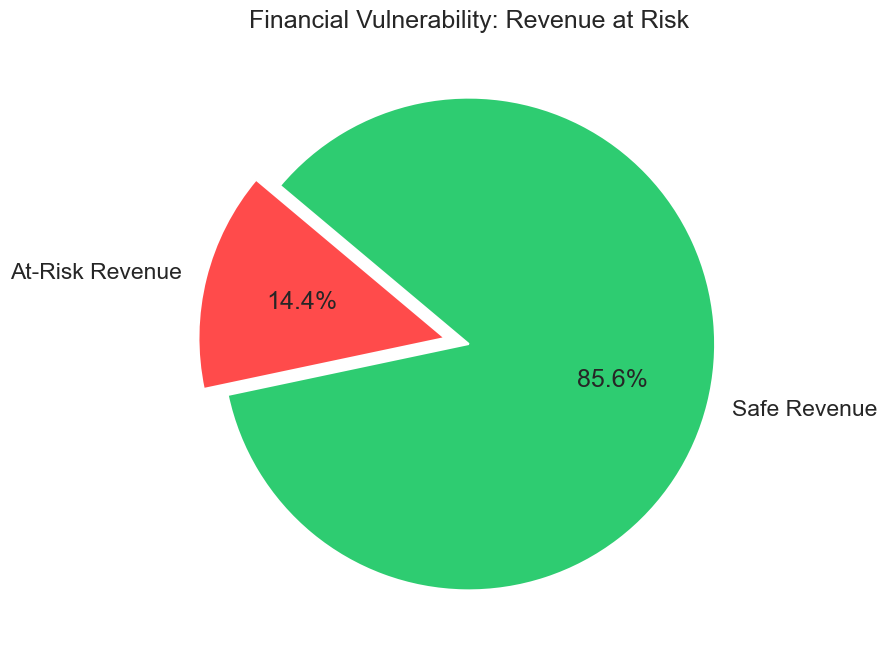

In [41]:
# Data for plotting
labels = ['At-Risk Revenue', 'Safe Revenue']
sizes = [mrr_at_risk, total_mrr - mrr_at_risk]
colors = ['#ff4b4b', '#2ecc71'] # Red for risk, Green for safe

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
plt.title('Financial Vulnerability: Revenue at Risk')
plt.show()

| Condition                             | Meaning                       | Why risky                                                 |
| ------------------------------------- | ----------------------------- | --------------------------------------------------------- |
| `Churn == 'No'`                       | Customer has **not left yet** | We want to identify customers who **may leave in future** |
| `Contract == 'Month-to-month'`        | No long-term commitment       | These customers can leave **anytime**                     |
| `InternetService == 'Fiber optic'`    | High price service            | Expensive services often show **higher churn**            |
| `PaymentMethod == 'Electronic check'` | Payment through e-check       | Historically **highest churn segment**                    |
---
Formula:


> ARR=MRR×12 (Formula: Annual Recurring Revenue (ARR) = Monthly Recurring Revenue * 12)

- total revenue at risk 14.4%

### 💰 Financial Vulnerability Analysis: Revenue at Risk

### Objective
The goal of this analysis is to identify **how much revenue is at risk** from customers who are currently active but belong to a **high-churn risk segment**.

These customers fall into the **"Danger Zone"** based on behavioral patterns observed in churn analysis.

---

### 🔎 High-Risk Customer Profile

Customers were classified as **high risk** if they meet all of the following conditions:

- **Churn Status:** Currently Active (`Churn = No`)
- **Contract Type:** Month-to-Month (no long-term commitment)
- **Internet Service:** Fiber Optic (historically highest churn segment)
- **Payment Method:** Electronic Check (associated with higher churn probability)

This segment represents customers who **have not churned yet but exhibit strong churn indicators.**

---

### 📊 Key Business Metrics

---

| **Metric** | **Value**                          |
|------------|------------------|
| Total Company Monthly Revenue | **$316,530.15** |
| High-Risk Customers Remaining | **518** |
| Monthly Revenue at Risk (MRR) | **$45,666.60** |
| Annual Revenue Exposure (ARR) | **$547,999.20** |
| % Revenue in Danger Zone | **14.43%** |
---

## ⚠️ Revenue Risk Insight

Approximately **14.43% of the company's total monthly revenue** is generated from customers in the **high-risk churn segment**.

If these customers churn:

- The company could lose **$45,666 per month**
- Equivalent to **$547,999 per year**

This represents a **significant financial vulnerability** that requires proactive retention strategies.

---

## 📈 Visualization Insight

The pie chart illustrates the proportion of **revenue at risk vs safe revenue**:

- **85.6% Safe Revenue** → Stable customers
- **14.4% At-Risk Revenue** → Customers likely to churn

This highlights that while the majority of revenue is stable, a **notable portion is vulnerable to churn.**

---

## 🧠 Business Recommendation

To protect this revenue, the company should focus on **targeted retention strategies** such as:

- Offering **discounted annual contracts** to month-to-month customers
- Providing **loyalty incentives** for fiber optic users
- Encouraging **automatic payment methods** instead of electronic checks
- Deploying **personalized retention campaigns** for high-risk customers

By proactively addressing this segment, the company can **reduce churn risk and protect nearly half a million dollars in annual revenue.**

In [43]:
# 1. Create Tenure Groups (0-12, 12-24, etc.)
labels = ["0-1 Year", "1-2 Years", "2-3 Years", "3-4 Years", "4-5 Years", "5+ Years"]
df['Tenure_Group'] = pd.cut(df.tenure, bins=[0, 12, 24, 36, 48, 60, 72], labels=labels)

# 2. Calculate Churn Rate per Group
tenure_churn = df.groupby('Tenure_Group')['Churn_Numeric'].mean() * 100

In [44]:
# 3. Create a pivot to see Tenure vs Contract Churn
waterfall = df.pivot_table(index='Tenure_Group', 
                           columns='Contract', 
                           values='Churn_Numeric', 
                           aggfunc='mean') * 100

In [46]:
waterfall

Contract,Month-to-month,One year,Two year
Tenure_Group,,,
0-1 Year,51.354062,10.569106,0.000000
1-2 Years,37.720488,8.121827,0.000000
2-3 Years,32.510288,8.000000,2.083333
3-4 Years,33.544304,13.059701,2.247191
4-5 Years,27.777778,13.707165,3.971119
5+ Years,22.222222,12.140575,3.144016


                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


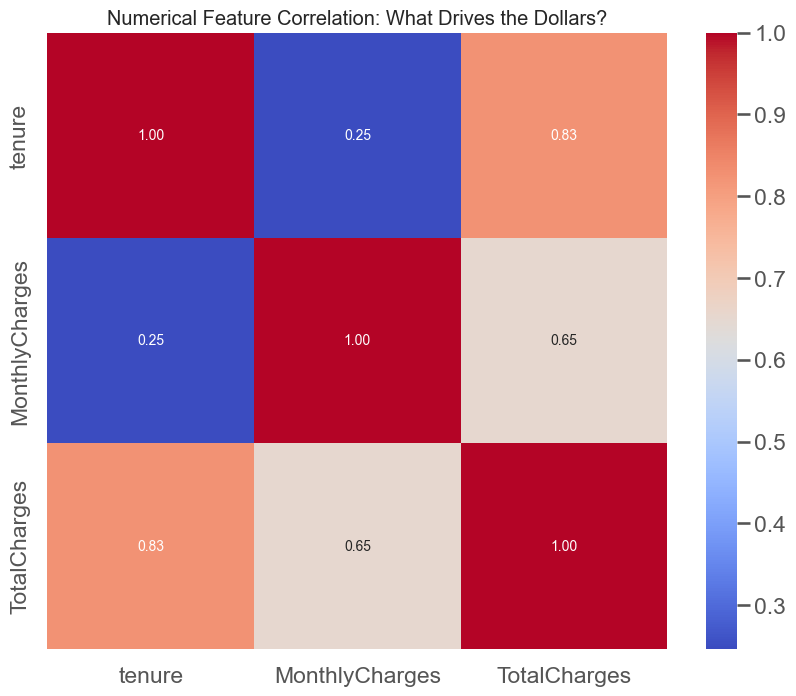

In [48]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[numerical_cols].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Feature Correlation: What Drives the Dollars?')
print(corr_matrix)
plt.show()

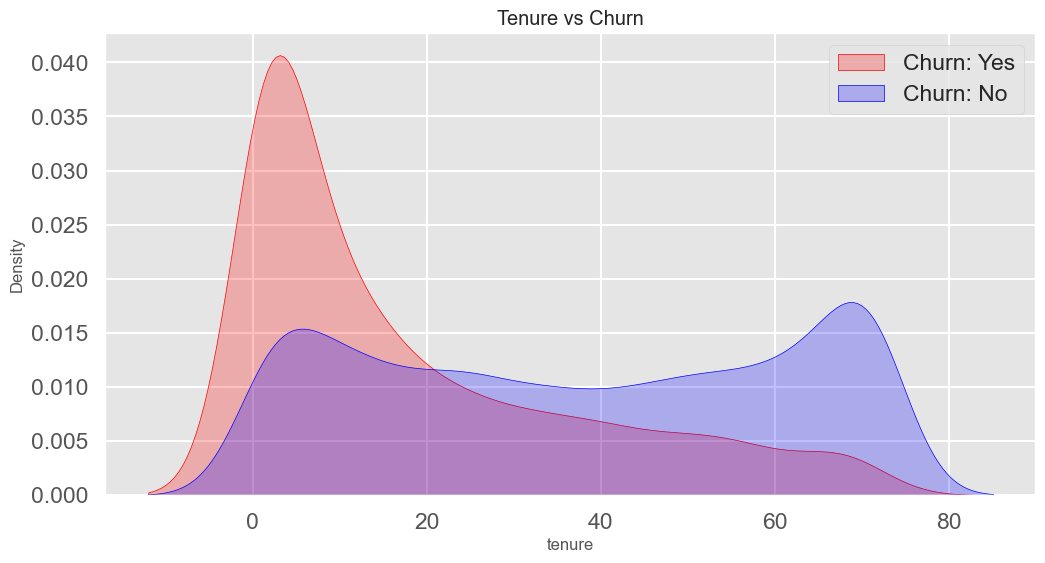

In [50]:
plt.figure(figsize = (12, 6))
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], color='red', fill=True, label='Churn: Yes')
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], color='blue', fill=True, label='Churn: No')
plt.title('Tenure vs Churn')
plt.legend()
plt.show()

### Oulier Detection

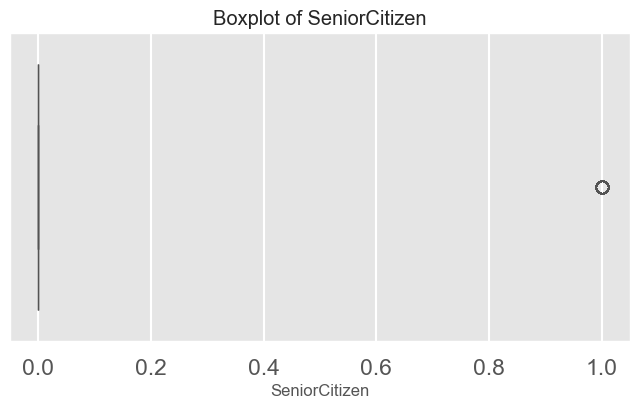

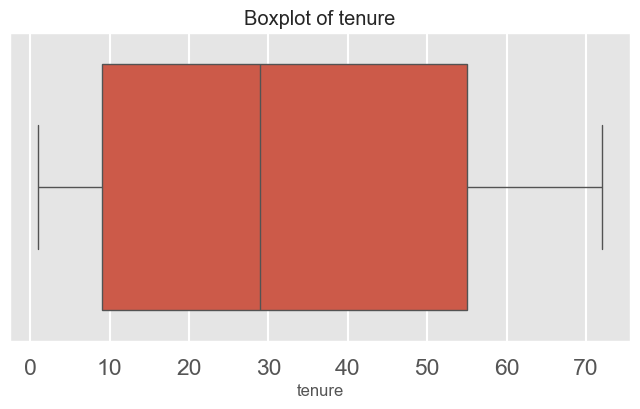

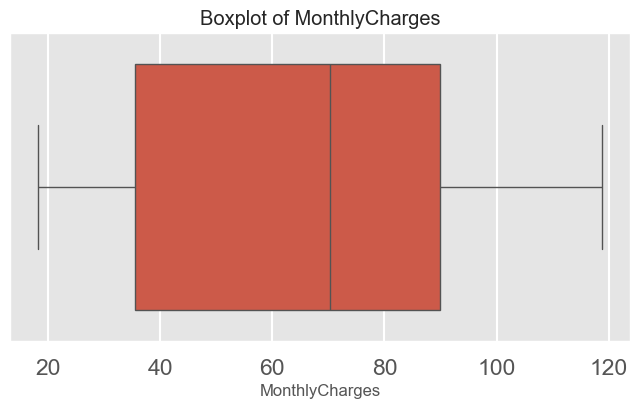

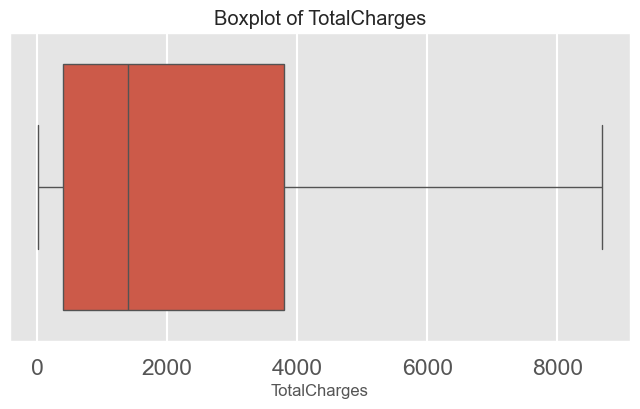

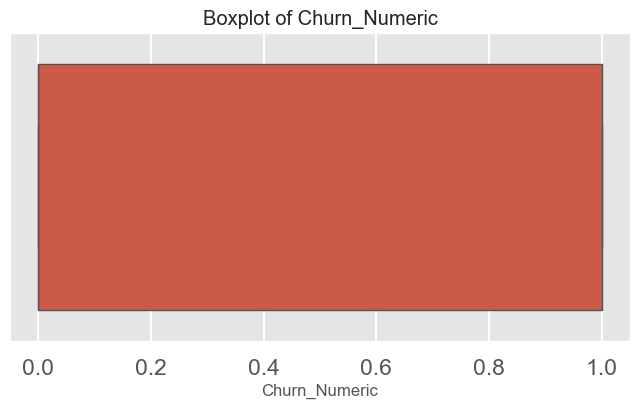

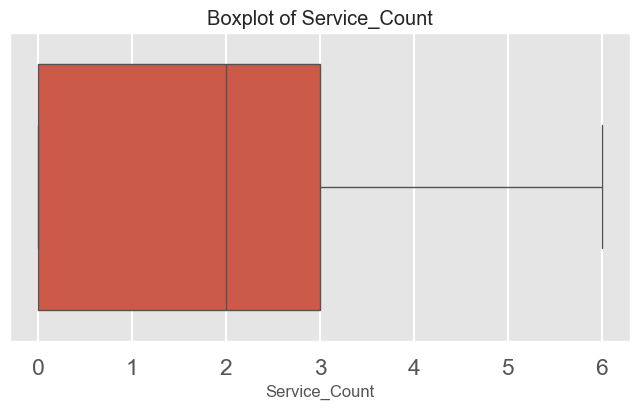

In [51]:
for i in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(8, 4)) 
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

In [57]:
# 1. CLEAN TARGET COLUMN
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})
df['Churn'] = pd.to_numeric(df['Churn'], errors='coerce')

####  FEATURE ENGINEERING

In [55]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']

df['Total_Services'] = (df[services] == 'Yes').sum(axis=1)
df['Is_Solo'] = ((df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)
df['Is_Auto_Pay'] = df['PaymentMethod'].apply(lambda x: 1 if isinstance(x, str) and 'automatic' in x else 0)
df['Short_Contract'] = (df['Contract'] == 'Month-to-month').astype(int)
df['Charge_Spike'] = df['MonthlyCharges'] - (df['TotalCharges'] / (df['tenure'] + 0.001))

####  FIX TEXT TRAPS BEFORE ENCODING

In [58]:

# Replace "No internet service" with "No" to prevent duplicate dummy columns
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].replace({'No internet service': 'No'})


# 4. DROP USELESS COLUMNS
drop_cols = [
    'customerID', 'gender', 'PhoneService', 'MultipleLines', 
    'Churn_Numeric',          # Target variable (if you created this earlier)
    'Service_Count',          # Duplicate of Total_Services
    'Tenure_Group_1-2 Years', # Redundant to raw 'tenure' (if already created)
    'Tenure_Group_2-3 Years',
    'Tenure_Group_3-4 Years',
    'Tenure_Group_4-5 Years',
    'Tenure_Group_5+ Years',
    'Contract_One year',      # Redundant to Short_Contract (if already created)
    'Contract_Two year',
    'Tenure_Group',           # Original categorical column
    'Contract',               # Original categorical column
    'Partner',                # Replaced by Is_Solo
    'Dependents'              # Replaced by Is_Solo
]

df = df.drop(columns=drop_cols, errors='ignore')

# 5. CREATE X and y, THEN ONE-HOT ENCODE
# CORRECTED: Added 'Churn' and axis=1 inside drop()
X_raw = df.drop('Churn', axis=1) 
y = df['Churn'].astype(int)

# One-Hot Encode (dtype=int makes the output 0 and 1 instead of True/False!)
X = pd.get_dummies(X_raw, drop_first=True, dtype=int)

print(f"Features shape after encoding: {X.shape}")

Features shape after encoding: (7032, 21)


In [59]:
df.to_csv("output.csv", index=False)